# YZ50 - 1. Hafta: Neural Networks (Sinir Ağları)

Konular: neuron, layer, parameter, loss, forward pass, gradient descent sezgisi.

Kaynaklar:
1. 3Blue1Brown, [But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk)
2. 3Blue1Brown, [Gradient descent, how neural networks learn](https://www.youtube.com/watch?v=IHZwWFHWa-w)
3. Andrej Karpathy, [The spelled-out intro to neural networks](https://www.youtube.com/watch?v=VMj-3S1tku0) (ilk 19 dakika, sayısal türev)


## Görev 1: Tek nöron forward pass (kütüphane kullanmadan)

Bir nöron: girişlerin ağırlıklarla çarpılıp toplanması (+ bias), ardından bir aktivasyon fonksiyonundan geçirilmesi.

In [1]:
import math


def sigmoid(z):
    return 1 / (1 + math.exp(-z))


def neuron_forward(inputs, weights, bias, activation=sigmoid):
    weighted_sum = sum(i * w for i, w in zip(inputs, weights)) + bias
    return activation(weighted_sum)


inputs = [1.0, 2.0, -1.0]
weights = [0.5, -0.3, 0.8]
bias = 0.1

output = neuron_forward(inputs, weights, bias)
print(f"inputs:  {inputs}")
print(f"weights: {weights}")
print(f"bias:    {bias}")
print(f"output:  {output:.4f}")

inputs:  [1.0, 2.0, -1.0]
weights: [0.5, -0.3, 0.8]
bias:    0.1
output:  0.3100


## Görev 2: Birden fazla nörondan oluşan bir katman

Aynı girişleri farklı ağırlık/bias'a sahip birden çok nörondan geçiriyoruz.

In [2]:
def layer_forward(inputs, weights_list, biases, activation=sigmoid):
    return [
        neuron_forward(inputs, weights, bias, activation)
        for weights, bias in zip(weights_list, biases)
    ]


weights_list = [
    [0.5, -0.3, 0.8],
    [-0.2, 0.4, 0.1],
    [0.9, 0.9, -0.5],
    [0.1, -0.7, 0.3],
]
biases = [0.1, -0.2, 0.05, 0.0]

outputs = layer_forward(inputs, weights_list, biases)
print(f"inputs: {inputs}")
for i, out in enumerate(outputs):
    print(f"neuron {i}: output = {out:.4f}")

inputs: [1.0, 2.0, -1.0]
neuron 0: output = 0.3100
neuron 1: output = 0.5744
neuron 2: output = 0.9627
neuron 3: output = 0.1680


## Görev 3: Basit bir loss fonksiyonu

Mean Squared Error (MSE): tahminlerin hedeflerden ne kadar uzak olduğunu ölçer.

In [3]:
def mse_loss(predictions, targets):
    n = len(predictions)
    squared_errors = [(p - t) ** 2 for p, t in zip(predictions, targets)]
    return sum(squared_errors) / n


predictions = [0.8, 0.2, 0.6]
targets = [1.0, 0.0, 0.5]

loss = mse_loss(predictions, targets)
print(f"predictions: {predictions}")
print(f"targets:     {targets}")
print(f"MSE loss:    {loss:.4f}")

predictions: [0.8, 0.2, 0.6]
targets:     [1.0, 0.0, 0.5]
MSE loss:    0.0300


## Görev 4: Parametreyi manuel değiştirip loss eğrisini çizmek

Tek parametreli basit bir model: `y_pred = w * x`. `w`'yu bir aralıkta tarayıp loss'un nasıl değiştiğini gözlemliyoruz.

x=2.0, target=6.0
taranan aralıktaki en düşük loss: w=3.00, loss=0.0000


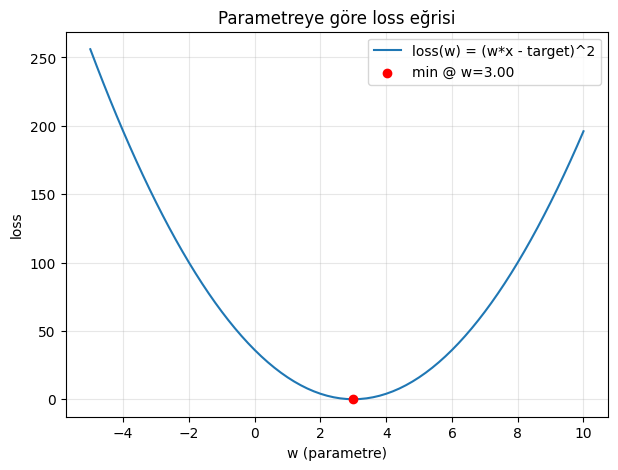

In [4]:
import matplotlib.pyplot as plt


def predict(w, x):
    return w * x


def squared_error(w, x, target):
    return (predict(w, x) - target) ** 2


x = 2.0
target = 6.0  # gerçek w = 3.0 olduğunda loss = 0 olur

ws = [w / 10 for w in range(-50, 101)]  # -5.0 .. 10.0 arası, 0.1 adımlarla
losses = [squared_error(w, x, target) for w in ws]

best_w = min(ws, key=lambda w: squared_error(w, x, target))
best_loss = squared_error(best_w, x, target)
print(f"x={x}, target={target}")
print(f"taranan aralıktaki en düşük loss: w={best_w:.2f}, loss={best_loss:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(ws, losses, label="loss(w) = (w*x - target)^2")
plt.scatter([best_w], [best_loss], color="red", zorder=5, label=f"min @ w={best_w:.2f}")
plt.xlabel("w (parametre)")
plt.ylabel("loss")
plt.title("Parametreye göre loss eğrisi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Görev 5: Sayısal türev ile gradient descent

Loss fonksiyonunun `w`'ye göre türevini analitik olarak değil, sayısal (numerical) olarak hesaplayıp `w`'yu küçük adımlarla güncelliyoruz.

In [5]:
def loss_fn(w, x, target):
    return (predict(w, x) - target) ** 2


def numerical_derivative(f, w, h=1e-5):
    return (f(w + h) - f(w - h)) / (2 * h)


w = 0.0  # başlangıç parametresi
lr = 0.05  # öğrenme oranı
steps = 60
history = []

for step in range(steps):
    f = lambda w_: loss_fn(w_, x, target)
    grad = numerical_derivative(f, w)
    w -= lr * grad
    history.append((step, w, f(w)))

    if step % 10 == 0 or step == steps - 1:
        print(f"step {step:3d}: w={w:.4f}, loss={f(w):.6f}, grad={grad:.4f}")

print(f"\nöğrenilen w: {w:.4f} (gerçek w: 3.0)")

step   0: w=1.2000, loss=12.960000, grad=-24.0000
step  10: w=2.9891, loss=0.000474, grad=-0.1451
step  20: w=2.9999, loss=0.000000, grad=-0.0009
step  30: w=3.0000, loss=0.000000, grad=-0.0000
step  40: w=3.0000, loss=0.000000, grad=-0.0000
step  50: w=3.0000, loss=0.000000, grad=-0.0000
step  59: w=3.0000, loss=0.000000, grad=-0.0000

öğrenilen w: 3.0000 (gerçek w: 3.0)


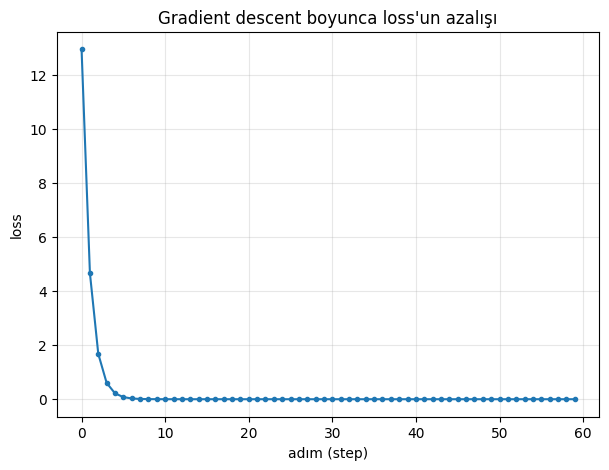

In [6]:
steps_hist, w_hist, loss_hist = zip(*history)

plt.figure(figsize=(7, 5))
plt.plot(steps_hist, loss_hist, marker="o", markersize=3)
plt.xlabel("adım (step)")
plt.ylabel("loss")
plt.title("Gradient descent boyunca loss'un azalışı")
plt.grid(True, alpha=0.3)
plt.show()